## Step 0 - Problem Statement and Proposed Solution

Pemantauan kualitas air permukaan secara kontinu saat ini sangat bergantung pada jaringan sensor Internet of Things (IoT). Meskipun mampu menghasilkan data dalam volume besar dengan resolusi waktu yang tinggi, sistem sensor IoT di lingkungan akuatik sangat rentan terhadap kegagalan teknis, seperti biofouling (penumpukan lumut/bakteri pada probe sensor), kehabisan daya, atau kerusakan kalibrasi, yang menghasilkan pembacaan data yang tidak valid. Di sisi lain, perubahan ekstrem pada kualitas air juga dapat disebabkan oleh kejadian nyata, seperti pembuangan limbah ilegal atau badai hujan yang menyebabkan lonjakan kekeruhan (turbidity) secara drastis. Tantangan komputasional utama dalam ranah ini adalah membedakan antara "fluktuasi ekstrem alami" dan "anomali sesungguhnya" (baik akibat kerusakan sensor maupun pencemaran) di tengah triliunan titik data yang tidak memiliki label (unlabeled data)

Metode deteksi ambang batas statis (static thresholding) tradisional terbukti tidak memadai karena parameter kualitas air bersifat sangat dinamis, multivariat, dan memiliki dependensi temporal (deret waktu). Misalnya, penurunan kadar Oksigen Terlarut (DO) mungkin dianggap normal jika terjadi pada malam hari atau saat suhu air sedang tinggi, namun menjadi anomali kritis jika terjadi secara tiba-tiba tanpa korelasi dengan parameter lain. Oleh karena itu, diperlukan rekayasa fitur (feature engineering) yang mengekstrak konteks historis—seperti rata-rata pergerakan mingguan (rolling mean) dan selisih harian (time-step difference)—agar algoritma dapat memahami pola siklus alami sungai sebelum mencoba mencari keanehan di dalamnya.

Untuk mengatasi ketiadaan label anomali pada data historis, pendekatan Unsupervised Machine Learning seperti Local Outlier Factor (LOF) dan One-Class Support Vector Machine (OCSVM) menjadi solusi yang paling optimal. Namun, evaluasi kinerja model unsupervised seringkali bersifat subjektif. Oleh karena itu, simulasi injeksi anomali sintetik (synthetic anomaly injection) yang merepresentasikan kerusakan sensor (univariat) dan pencemaran (multivariat) mutlak diperlukan sebagai ground truth objektif untuk mengukur metrik F1-Score model pada saat pengujian.

Lebih lanjut, setiap algoritma unsupervised memiliki kelemahan bawaan (blind spots); algoritma berbasis kepadatan lokal (seperti LOF) mungkin unggul dalam mendeteksi lonjakan tiba-tiba, sementara algoritma berbasis batas (seperti OCSVM) lebih baik dalam melihat penyimpangan secara global. Untuk menekan tingginya angka False Positive yang sering menjangkiti sistem deteksi anomali tunggal, penerapan Heterogeneous Ensemble berbasis Majority Vote diusulkan sebagai strategi penggabungan keputusan. Pada akhirnya, kontribusi dari seluruh rekayasa komputasional ini harus divalidasi melalui studi ablasi (ablation study) guna membuktikan secara empiris bahwa ekstraksi fitur deret waktu secara signifikan meningkatkan kemampuan model dibandingkan jika hanya menggunakan data mentah sensor.

## Step 1 - Install Library

In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import f1_score, classification_report, accuracy_score

## Step 2 - Data Loading and Initial Inspection

In [161]:
df_raw = pd.read_csv("../data/clackamas_river.csv")

In [162]:
rename_dict = {
    "00010_Mean": "Temperature",
    "00300_Mean": "Dissolved Oxygen",
    "00400_Median": "pH",
    "63680_Median": "Turbidity"
}

In [163]:
selected_columns = ['datetime'] + list(rename_dict.keys())
df = df_raw[selected_columns].copy()

df = df.rename(columns=rename_dict)

In [164]:
df['datetime'] = pd.to_datetime(df['datetime'], utc=True, errors='coerce')

In [165]:
baris_rusak = df['datetime'].isna().sum()
print(f"Jumlah baris yang rusak dan diabaikan: {baris_rusak} baris")

Jumlah baris yang rusak dan diabaikan: 217 baris


In [166]:
df = df.dropna(subset=['datetime'])

In [167]:
df = df.set_index('datetime')

In [168]:
df = df.loc['2014':'2023']

In [169]:
print("\n--- Info Data Setelah Filter 10 Tahun ---")
print(df.info())


--- Info Data Setelah Filter 10 Tahun ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3562 entries, 2014-01-01 00:00:00+00:00 to 2023-12-31 00:00:00+00:00
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temperature       3560 non-null   float64
 1   Dissolved Oxygen  3541 non-null   float64
 2   pH                3522 non-null   float64
 3   Turbidity         3512 non-null   float64
dtypes: float64(4)
memory usage: 139.1 KB
None


## Step 3 - Exploratory Data Analysis (EDA)

In [170]:
print("--- Statistik Deskriptif ---")
print(df.describe())


--- Statistik Deskriptif ---
       Temperature  Dissolved Oxygen           pH    Turbidity
count  3560.000000       3541.000000  3522.000000  3512.000000
mean     11.504775         11.134425     7.526917     2.579584
std       5.604703          1.414884     0.269678     4.771787
min       0.900000          8.200000     6.800000     0.100000
25%       6.700000          9.900000     7.300000     0.800000
50%      10.100000         11.400000     7.500000     1.400000
75%      16.200000         12.300000     7.700000     2.500000
max      23.900000         14.500000     8.400000    91.600000


In [171]:
full_date_range = pd.date_range(start='2014-01-01', end='2023-12-31', freq='D', tz='UTC')

missing_dates = full_date_range.difference(df.index)
print("\n--- Laporan Hari yang Hilang ---")
print(f"Total hari yang hilang dari sensor: {len(missing_dates)} hari")
if len(missing_dates) > 0:
    print("Contoh 5 tanggal yang hilang:", [date.strftime('%Y-%m-%d') for date in missing_dates[:5]])


--- Laporan Hari yang Hilang ---
Total hari yang hilang dari sensor: 90 hari
Contoh 5 tanggal yang hilang: ['2014-10-05', '2014-10-06', '2014-11-21', '2014-11-22', '2014-11-23']


In [172]:
df = df.reindex(full_date_range)
df.index.name = 'datetime'

print(f"\nTotal baris setelah reindex: {len(df)} baris")


Total baris setelah reindex: 3652 baris


In [173]:
print("\n--- Total Nilai Kosong (NaN) per Fitur ---")
print(df.isna().sum())


--- Total Nilai Kosong (NaN) per Fitur ---
Temperature          92
Dissolved Oxygen    111
pH                  130
Turbidity           140
dtype: int64


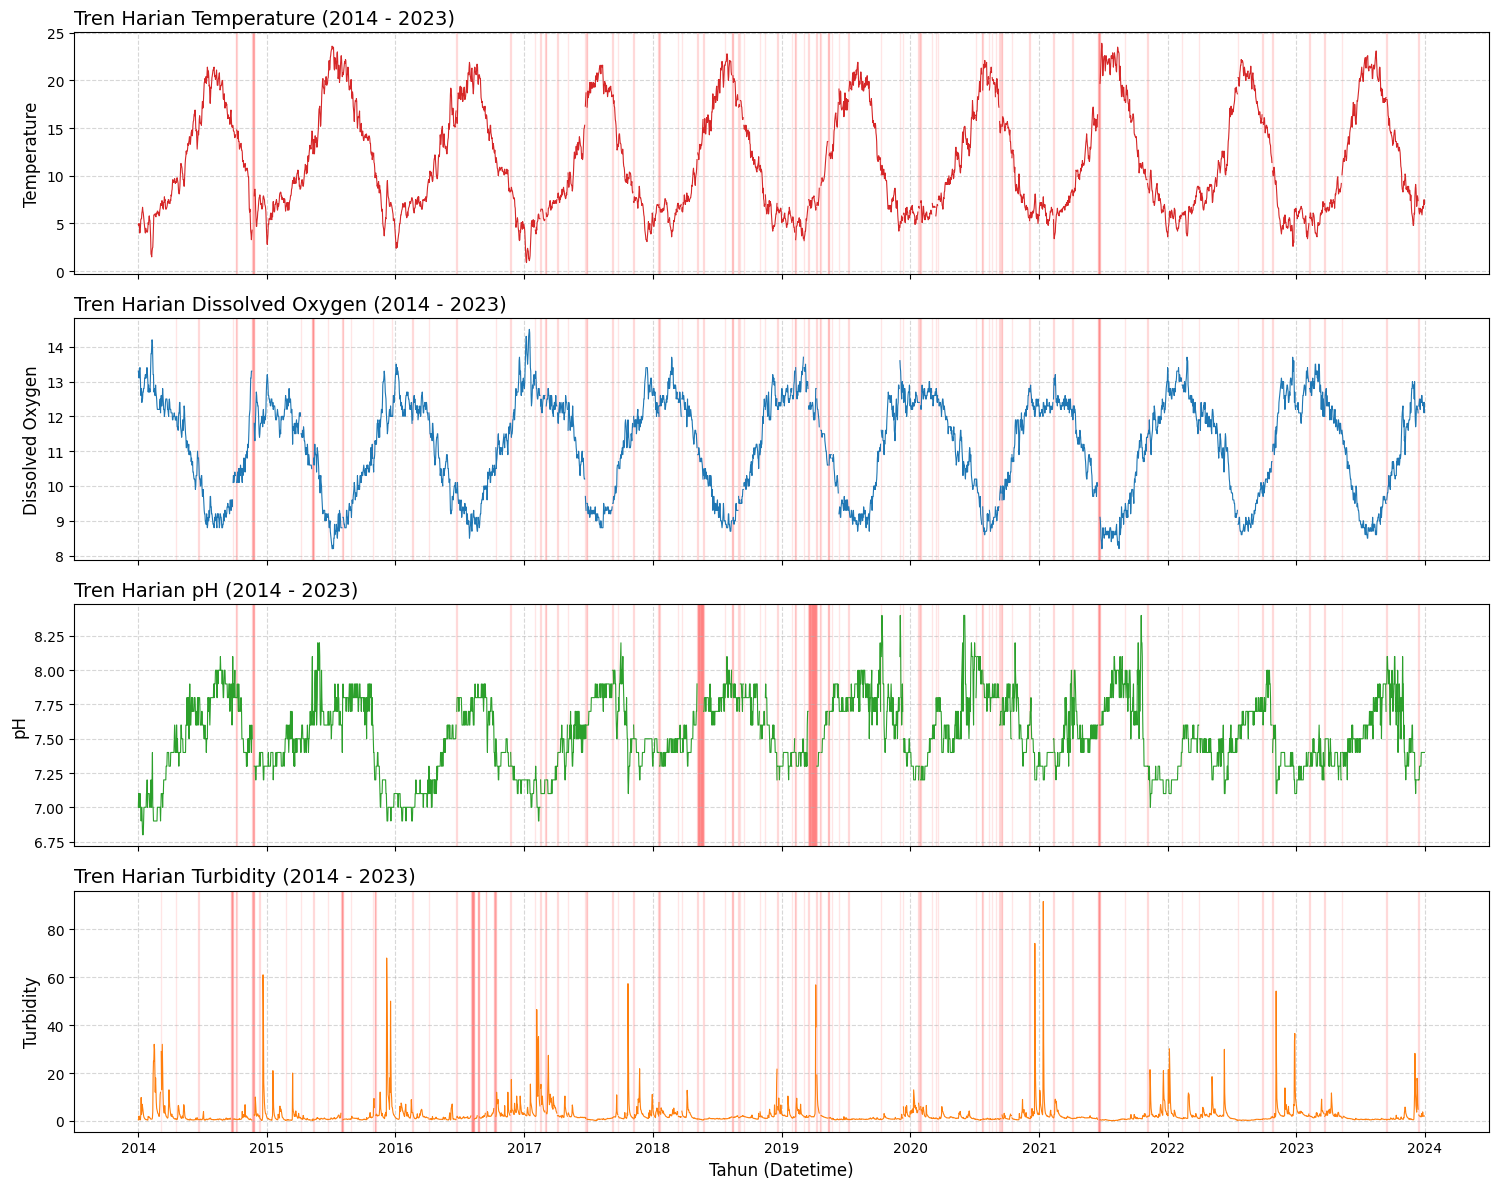

In [174]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 12), sharex=True)
features = ['Temperature', 'Dissolved Oxygen', 'pH', 'Turbidity']
colors = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e']

for i, col in enumerate(features):
    axes[i].plot(df.index, df[col], color=colors[i], linestyle='-', linewidth=0.8)
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].set_title(f"Tren Harian {col} (2014 - 2023)", fontsize=14, loc='left')
    axes[i].grid(True, linestyle='--', alpha=0.5)
    
    missing_mask = df[col].isna()
    for j in range(len(missing_mask) - 1):
        if missing_mask.iloc[j]:
            axes[i].axvspan(df.index[j], df.index[j+1], color='red', alpha=0.1)

plt.xlabel("Tahun (Datetime)", fontsize=12)
plt.tight_layout()
plt.show()

### Step 3.A - Temperature

In [175]:
fig = px.histogram(
    df, 
    x='Temperature', 
    marginal="box", 
    title="Distribusi dan Boxplot Historis: Temperature",
    color_discrete_sequence=['#EF553B'],
    opacity=0.8,
    nbins=50 
)

fig.update_layout(
    xaxis_title="Nilai Temperature",
    yaxis_title="Frekuensi (Jumlah Hari)",
    bargap=0.05,
    plot_bgcolor='white'
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')

fig.show()

### Step 3.B - Dissolved Oxygen

In [176]:
fig = px.histogram(
    df, 
    x='Dissolved Oxygen', 
    marginal="box", 
    title="Distribusi dan Boxplot Historis: Dissolved Oxygen",
    color_discrete_sequence=['#00CC96'],
    opacity=0.8,
    nbins=50 
)

fig.update_layout(
    xaxis_title="Nilai Dissolved Oxygen",
    yaxis_title="Frekuensi (Jumlah Hari)",
    bargap=0.05,
    plot_bgcolor='white'
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')

fig.show()

### Step 3.C - pH

In [177]:
fig = px.histogram(
    df, 
    x='pH', 
    marginal="box", 
    title="Distribusi dan Boxplot Historis: pH",
    color_discrete_sequence=['#AB63FA'],
    opacity=0.8,
    nbins=50 
)

fig.update_layout(
    xaxis_title="Nilai pH",
    yaxis_title="Frekuensi (Jumlah Hari)",
    bargap=0.05,
    plot_bgcolor='white'
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')

fig.show()

### Step 3.D - Turbidity

In [178]:
fig = px.histogram(
    df, 
    x='Turbidity', 
    marginal="box", 
    title="Distribusi dan Boxplot Historis: Turbidity",
    color_discrete_sequence=['#FFA15A'],
    opacity=0.8,
    nbins=50 
)

fig.update_layout(
    xaxis_title="Nilai Turbidity",
    yaxis_title="Frekuensi (Jumlah Hari)",
    bargap=0.05,
    plot_bgcolor='white'
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')

fig.show()

### Step 3.E - Correlation Matrix

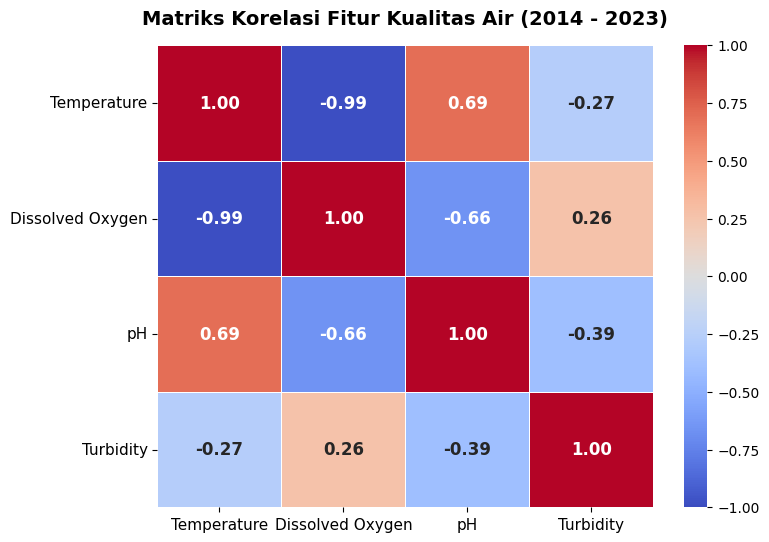

In [179]:
corr_matrix = df[features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f",
    linewidths=0.5, 
    vmin=-1, 
    vmax=1,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title("Matriks Korelasi Fitur Kualitas Air (2014 - 2023)", fontsize=14, fontweight='bold', pad=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.show()

## Step 3 - Data Cleaning and Imputation

In [180]:
print("--- Missing Values SEBELUM Imputasi ---")
print(df.isna().sum())

--- Missing Values SEBELUM Imputasi ---
Temperature          92
Dissolved Oxygen    111
pH                  130
Turbidity           140
dtype: int64


In [181]:
df = df.bfill().ffill()

In [182]:
print("\n--- Missing Values SESUDAH Imputasi ---")
print(df.isna().sum())


--- Missing Values SESUDAH Imputasi ---
Temperature         0
Dissolved Oxygen    0
pH                  0
Turbidity           0
dtype: int64


In [183]:
print("\n--- 5 Baris Pertama Data Bersih ---")
print(df.head())


--- 5 Baris Pertama Data Bersih ---
                           Temperature  Dissolved Oxygen   pH  Turbidity
datetime                                                                
2014-01-01 00:00:00+00:00          4.9              13.3  7.0        0.5
2014-01-02 00:00:00+00:00          4.8              13.2  7.1        0.5
2014-01-03 00:00:00+00:00          5.0              13.1  7.0        2.1
2014-01-04 00:00:00+00:00          4.6              13.3  7.1        1.0
2014-01-05 00:00:00+00:00          4.0              13.4  7.0        0.6


## Step 4 - Feature Engineering

In [184]:
df_feat = df.copy()

In [185]:
df_feat['Month_Sin'] = np.sin(2 * np.pi * df_feat.index.month / 12)
df_feat['Month_Cos'] = np.cos(2 * np.pi * df_feat.index.month / 12)

In [186]:
df['Turbidity'] = np.log1p(df['Turbidity'])

In [187]:
for col in features:
    df_feat[f'{col}_Diff'] = df_feat[col].diff()
    df_feat[f'{col}_Mean_7D'] = df_feat[col].rolling(window=7, min_periods=1).mean()
    df_feat[f'{col}_Std_7D'] = df_feat[col].rolling(window=7, min_periods=2).std()

In [188]:
df_feat = df_feat.bfill()

In [189]:
print("--- Info Struktur Data Baru ---")
print(df_feat.info())

--- Info Struktur Data Baru ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3652 entries, 2014-01-01 00:00:00+00:00 to 2023-12-31 00:00:00+00:00
Freq: D
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               3652 non-null   float64
 1   Dissolved Oxygen          3652 non-null   float64
 2   pH                        3652 non-null   float64
 3   Turbidity                 3652 non-null   float64
 4   Month_Sin                 3652 non-null   float64
 5   Month_Cos                 3652 non-null   float64
 6   Temperature_Diff          3652 non-null   float64
 7   Temperature_Mean_7D       3652 non-null   float64
 8   Temperature_Std_7D        3652 non-null   float64
 9   Dissolved Oxygen_Diff     3652 non-null   float64
 10  Dissolved Oxygen_Mean_7D  3652 non-null   float64
 11  Dissolved Oxygen_Std_7D   3652 non-null   float64
 12  pH_Diff                   3652

In [190]:
print("\n--- Contoh Hasil Rekayasa Fitur (Fokus di Temperature) ---")
cols_to_show = ['Temperature', 'Temperature_Diff', 'Temperature_Mean_7D', 'Temperature_Std_7D']
print(df_feat[cols_to_show].head())


--- Contoh Hasil Rekayasa Fitur (Fokus di Temperature) ---
                           Temperature  Temperature_Diff  Temperature_Mean_7D  \
datetime                                                                        
2014-01-01 00:00:00+00:00          4.9              -0.1                4.900   
2014-01-02 00:00:00+00:00          4.8              -0.1                4.850   
2014-01-03 00:00:00+00:00          5.0               0.2                4.900   
2014-01-04 00:00:00+00:00          4.6              -0.4                4.825   
2014-01-05 00:00:00+00:00          4.0              -0.6                4.660   

                           Temperature_Std_7D  
datetime                                       
2014-01-01 00:00:00+00:00            0.070711  
2014-01-02 00:00:00+00:00            0.070711  
2014-01-03 00:00:00+00:00            0.100000  
2014-01-04 00:00:00+00:00            0.170783  
2014-01-05 00:00:00+00:00            0.397492  


## Step 5 - Data Splitting

In [191]:
train_df = df_feat.loc['2014':'2020'].copy()
val_df   = df_feat.loc['2021'].copy()
test_df  = df_feat.loc['2022':'2023'].copy()

## Step 6 - Standardization

In [192]:
cyclical_cols = ['Month_Sin', 'Month_Cos']
cols_to_scale = [col for col in train_df.columns if col not in cyclical_cols]

In [193]:
scaler = RobustScaler()
scaler.fit(train_df[cols_to_scale])

,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


In [194]:
def scale_dataframe(df_target, scaler_obj, scale_cols, pass_cols):
    scaled_array = scaler_obj.transform(df_target[scale_cols])
    df_scaled = pd.DataFrame(scaled_array, columns=scale_cols, index=df_target.index)
    
    df_final = pd.concat([df_scaled, df_target[pass_cols]], axis=1)
    return df_final

In [195]:
train_scaled = scale_dataframe(train_df, scaler, cols_to_scale, cyclical_cols)
val_scaled   = scale_dataframe(val_df, scaler, cols_to_scale, cyclical_cols)
test_scaled  = scale_dataframe(test_df, scaler, cols_to_scale, cyclical_cols)

In [196]:
print("--- Contoh Data Train Set Setelah Revisi ---")
print(train_scaled[['Temperature', 'Turbidity', 'Month_Sin', 'Month_Cos']].head())

--- Contoh Data Train Set Setelah Revisi ---
                           Temperature  Turbidity  Month_Sin  Month_Cos
datetime                                                               
2014-01-01 00:00:00+00:00    -0.569892  -0.529412        0.5   0.866025
2014-01-02 00:00:00+00:00    -0.580645  -0.529412        0.5   0.866025
2014-01-03 00:00:00+00:00    -0.559140   0.411765        0.5   0.866025
2014-01-04 00:00:00+00:00    -0.602151  -0.235294        0.5   0.866025
2014-01-05 00:00:00+00:00    -0.666667  -0.470588        0.5   0.866025


## Step 7 - Synthetic Anomaly Injection

In [197]:
np.random.seed(42)

In [198]:
val_scaled['Label'] = 0
test_scaled['Label'] = 0

In [199]:
def inject_anomalies(df, num_univariate=5, num_multivariate=5):
    df_injected = df.copy()
    
    # --- SKENARIO 1: UNIVARIAT
    random_dates_uni = np.random.choice(df_injected.index, size=num_univariate, replace=False)
    
    for date in random_dates_uni:
        df_injected.loc[date, 'Turbidity'] += 5.0
        
        df_injected.loc[date, 'Label'] = 1
        
    # --- SKENARIO 2: MULTIVARIAT
    remaining_dates = df_injected[df_injected['Label'] == 0].index
    random_dates_multi = np.random.choice(remaining_dates, size=num_multivariate, replace=False)
    
    for date in random_dates_multi:
        df_injected.loc[date, 'Temperature'] += 5.0
        df_injected.loc[date, 'Dissolved Oxygen'] -= 5.0
        
        df_injected.loc[date, 'Label'] = 1
        
    return df_injected

In [200]:
val_injected = inject_anomalies(val_scaled, num_univariate=36, num_multivariate=36)
test_injected = inject_anomalies(test_scaled, num_univariate=72, num_multivariate=72)

In [201]:
print("--- Laporan Ground Truth Buatan ---")
print(f"Total Hari Normal di Validation Set  : {len(val_injected[val_injected['Label'] == 0])}")
print(f"Total Hari Anomali di Validation Set : {len(val_injected[val_injected['Label'] == 1])}")
print(f"Total Hari Normal di Test Set        : {len(test_injected[test_injected['Label'] == 0])}")
print(f"Total Hari Anomali di Test Set       : {len(test_injected[test_injected['Label'] == 1])}")

--- Laporan Ground Truth Buatan ---
Total Hari Normal di Validation Set  : 293
Total Hari Anomali di Validation Set : 72
Total Hari Normal di Test Set        : 586
Total Hari Anomali di Test Set       : 144


In [202]:
print("\n--- Contoh Data Anomali Multivariat di Test Set ---")
contoh_multi = test_injected[test_injected['Label'] == 1].tail(3)
print(contoh_multi[['Temperature', 'Dissolved Oxygen', 'Turbidity', 'Label']])


--- Contoh Data Anomali Multivariat di Test Set ---
                           Temperature  Dissolved Oxygen  Turbidity  Label
datetime                                                                  
2023-12-14 00:00:00+00:00     4.612903         -4.625000   0.647059      1
2023-12-20 00:00:00+00:00    -0.419355          0.416667   5.352941      1
2023-12-21 00:00:00+00:00     4.569892         -4.541667   0.176471      1


## Step 8 - Model Training and Evaluation

In [203]:
class AnomalyPipeline:
    def __init__(self, model_name):
        self.model_name = model_name.upper()
        
        if self.model_name == 'LOF':
            self.model = LocalOutlierFactor(n_neighbors=20, novelty=True) 
        elif self.model_name == 'OCSVM':
            self.model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.01)
        else:
            raise ValueError("Model tidak valid. Pilih 'LOF' atau 'OCSVM'.")

    def run_baseline(self, train_df, test_df, features):
        print(f"\n --- MENJALANKAN PIPELINE: {self.model_name} ---")
        
        self.model.fit(train_df[features])

        preds = self.model.predict(test_df[features])
        preds_mapped = [1 if x == -1 else 0 for x in preds]
        
        scores = -1 * self.model.decision_function(test_df[features])

        print(classification_report(test_df['Label'], preds_mapped, target_names=['Normal', 'Anomali'], zero_division=0))

        fig, ax = plt.subplots(figsize=(15, 5))
        
        ax.plot(test_df.index, scores, color='gray', alpha=0.6, label=f'Anomaly Score ({self.model_name})')
        ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Threshold (Score > 0 = Anomali)')
        
        anomali_asli = test_df[test_df['Label'] == 1]
        tebakan_model = test_df[[p == 1 for p in preds_mapped]]
        
        ax.scatter(anomali_asli.index, scores[test_df['Label'] == 1], color='blue', s=120, label='Ground Truth', edgecolors='black', zorder=5)
        ax.scatter(tebakan_model.index, scores[[p == 1 for p in preds_mapped]], color='red', s=80, marker='x', label='Prediksi', zorder=6)

        ax.set_title(f"Deteksi Anomali Kualitas Air - {self.model_name} (Baseline)", fontsize=14, fontweight='bold')
        ax.set_ylabel("Anomaly Score")
        ax.legend(loc='upper right')
        ax.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

        return preds_mapped

### Step 8.A - Train LOF


 --- MENJALANKAN PIPELINE: LOF ---
              precision    recall  f1-score   support

      Normal       0.92      0.86      0.89       293
     Anomali       0.54      0.68      0.60        72

    accuracy                           0.82       365
   macro avg       0.73      0.77      0.75       365
weighted avg       0.84      0.82      0.83       365



C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


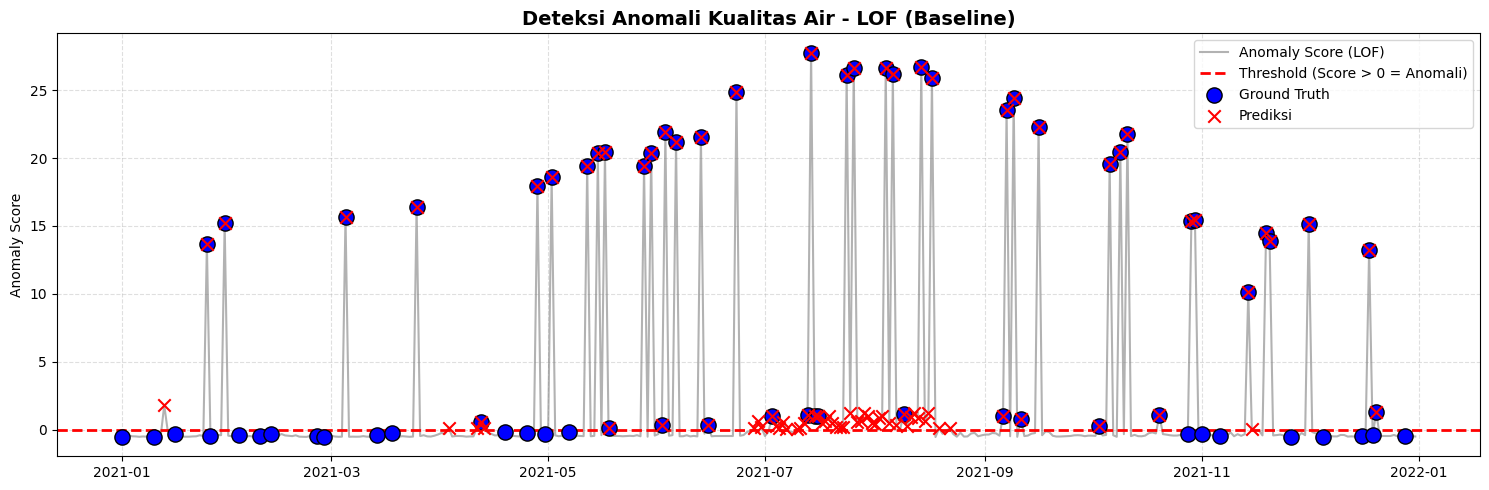

In [204]:
pipeline_lof = AnomalyPipeline('LOF')
prediksi_final_lof = pipeline_lof.run_baseline(train_scaled, val_injected, features)


 --- MENJALANKAN PIPELINE: OCSVM ---
              precision    recall  f1-score   support

      Normal       0.92      0.94      0.93       293
     Anomali       0.73      0.68      0.71        72

    accuracy                           0.89       365
   macro avg       0.83      0.81      0.82       365
weighted avg       0.89      0.89      0.89       365



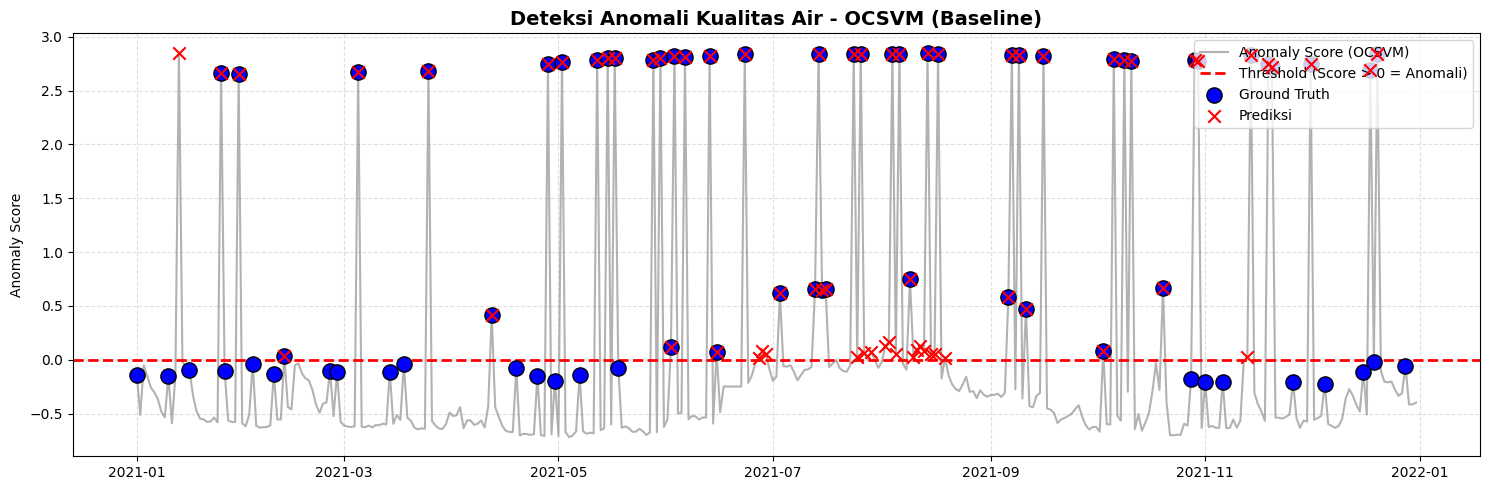

In [205]:
pipeline_svm = AnomalyPipeline('OCSVM')
prediksi_final_svm = pipeline_svm.run_baseline(train_scaled, val_injected, features)

## Step 9 - Hyperparameter Tuning

### Step 9.A - LOF Model

In [206]:
lof_neighbors = [10, 20, 30, 50]
lof_contaminations = [0.01, 0.03, 0.05, 0.1]

lof_results = []
best_lof_f1 = 0
best_lof_params = {}

for n in lof_neighbors:
    for c in lof_contaminations:
        model = LocalOutlierFactor(n_neighbors=n, contamination=c, novelty=True)
        
        model.fit(train_scaled[features].values)

        preds = model.predict(val_injected[features].values)
        preds_mapped = [1 if x == -1 else 0 for x in preds]
        
        acc = accuracy_score(val_injected['Label'], preds_mapped)
        f1 = f1_score(val_injected['Label'], preds_mapped, zero_division=0)
        
        lof_results.append({'n_neighbors': n, 'contamination': c, 'Accuracy': acc, 'F1-Score': f1})
        
        print(f"Uji n_neighbors={n:2d}, contamination={c:.2f} | Akurasi: {acc:.4f} | F1-Score: {f1:.4f}")
        
        if f1 > best_lof_f1:
            best_lof_f1 = f1
            best_lof_params = {'n_neighbors': n, 'contamination': c}

print(f"\n[LOF TERBAIK] {best_lof_params} dengan F1-Score: {best_lof_f1:.4f}\n")

Uji n_neighbors=10, contamination=0.01 | Akurasi: 0.8356 | F1-Score: 0.6154
Uji n_neighbors=10, contamination=0.03 | Akurasi: 0.8000 | F1-Score: 0.5922
Uji n_neighbors=10, contamination=0.05 | Akurasi: 0.7589 | F1-Score: 0.5600
Uji n_neighbors=10, contamination=0.10 | Akurasi: 0.7178 | F1-Score: 0.5253
Uji n_neighbors=20, contamination=0.01 | Akurasi: 0.8466 | F1-Score: 0.6316
Uji n_neighbors=20, contamination=0.03 | Akurasi: 0.8137 | F1-Score: 0.5904
Uji n_neighbors=20, contamination=0.05 | Akurasi: 0.7918 | F1-Score: 0.5682
Uji n_neighbors=20, contamination=0.10 | Akurasi: 0.7589 | F1-Score: 0.5556
Uji n_neighbors=30, contamination=0.01 | Akurasi: 0.8575 | F1-Score: 0.6438
Uji n_neighbors=30, contamination=0.03 | Akurasi: 0.8137 | F1-Score: 0.5904
Uji n_neighbors=30, contamination=0.05 | Akurasi: 0.7890 | F1-Score: 0.5650
Uji n_neighbors=30, contamination=0.10 | Akurasi: 0.7699 | F1-Score: 0.5532
Uji n_neighbors=50, contamination=0.01 | Akurasi: 0.9068 | F1-Score: 0.7069
Uji n_neighb

In [207]:
print("--- LAPORAN KLASIFIKASI LOF TERBAIK (VALIDATION SET) ---")
final_lof = LocalOutlierFactor(
    n_neighbors=best_lof_params['n_neighbors'], 
    contamination=best_lof_params['contamination'], 
    novelty=True
)

final_lof.fit(train_scaled[features].values)
final_preds = final_lof.predict(val_injected[features].values)
final_preds_mapped = [1 if x == -1 else 0 for x in final_preds]

print(classification_report(val_injected['Label'], final_preds_mapped, target_names=['Normal', 'Anomali'], zero_division=0))

--- LAPORAN KLASIFIKASI LOF TERBAIK (VALIDATION SET) ---
              precision    recall  f1-score   support

      Normal       0.90      0.99      0.94       293
     Anomali       0.93      0.57      0.71        72

    accuracy                           0.91       365
   macro avg       0.92      0.78      0.83       365
weighted avg       0.91      0.91      0.90       365



### Step 9.B - OCSVM Model

In [208]:
svm_nus = [0.01, 0.03, 0.05, 0.1]
svm_gammas = ['scale', 'auto', 0.01, 0.1]

svm_results = []
best_svm_f1 = 0
best_svm_params = {}

for nu in svm_nus:
    for g in svm_gammas:
        model = OneClassSVM(kernel='rbf', gamma=g, nu=nu)
        model.fit(train_scaled[features])
        
        preds = model.predict(val_injected[features])
        preds_mapped = [1 if x == -1 else 0 for x in preds]
        
        acc = accuracy_score(val_injected['Label'], preds_mapped)
        f1 = f1_score(val_injected['Label'], preds_mapped, zero_division=0)
        
        svm_results.append({'nu': nu, 'gamma': str(g), 'Accuracy': acc, 'F1-Score': f1})
        
        print(f"Uji nu={nu:.2f}, gamma={str(g):>5s} | Akurasi: {acc:.4f} | F1-Score: {f1:.4f}")
        
        if f1 > best_svm_f1:
            best_svm_f1 = f1
            best_svm_params = {'nu': nu, 'gamma': g}

print(f"[OCSVM TERBAIK] {best_svm_params} dengan F1-Score: {best_svm_f1:.4f}\n")

Uji nu=0.01, gamma=scale | Akurasi: 0.8877 | F1-Score: 0.7050
Uji nu=0.01, gamma= auto | Akurasi: 0.8767 | F1-Score: 0.6939
Uji nu=0.01, gamma= 0.01 | Akurasi: 0.8055 | F1-Score: 0.5035
Uji nu=0.01, gamma=  0.1 | Akurasi: 0.8795 | F1-Score: 0.6901
Uji nu=0.03, gamma=scale | Akurasi: 0.8548 | F1-Score: 0.6748
Uji nu=0.03, gamma= auto | Akurasi: 0.8685 | F1-Score: 0.6962
Uji nu=0.03, gamma= 0.01 | Akurasi: 0.7918 | F1-Score: 0.5000
Uji nu=0.03, gamma=  0.1 | Akurasi: 0.8521 | F1-Score: 0.6747
Uji nu=0.05, gamma=scale | Akurasi: 0.8438 | F1-Score: 0.6816
Uji nu=0.05, gamma= auto | Akurasi: 0.8630 | F1-Score: 0.7126
Uji nu=0.05, gamma= 0.01 | Akurasi: 0.7918 | F1-Score: 0.5190
Uji nu=0.05, gamma=  0.1 | Akurasi: 0.8466 | F1-Score: 0.6889
Uji nu=0.10, gamma=scale | Akurasi: 0.8466 | F1-Score: 0.7200
Uji nu=0.10, gamma= auto | Akurasi: 0.8411 | F1-Score: 0.7071
Uji nu=0.10, gamma= 0.01 | Akurasi: 0.8411 | F1-Score: 0.7129
Uji nu=0.10, gamma=  0.1 | Akurasi: 0.8466 | F1-Score: 0.7200
[OCSVM T

In [209]:
print("--- LAPORAN KLASIFIKASI OCSVM TERBAIK (VALIDATION SET) ---")

final_svm = OneClassSVM(
    kernel='rbf', 
    gamma=best_svm_params['gamma'], 
    nu=best_svm_params['nu']
)

final_svm.fit(train_scaled[features].values)
final_preds_svm = final_svm.predict(val_injected[features].values)
final_preds_mapped_svm = [1 if x == -1 else 0 for x in final_preds_svm]

print(classification_report(val_injected['Label'], final_preds_mapped_svm, target_names=['Normal', 'Anomali'], zero_division=0))

--- LAPORAN KLASIFIKASI OCSVM TERBAIK (VALIDATION SET) ---
              precision    recall  f1-score   support

      Normal       1.00      0.81      0.89       293
     Anomali       0.56      1.00      0.72        72

    accuracy                           0.85       365
   macro avg       0.78      0.90      0.81       365
weighted avg       0.91      0.85      0.86       365



## Step 10 - Final Model Evaluation

### Step 10.A - LOF Model


 --- MENJALANKAN PIPELINE: LOF ---
              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96       586
     Anomali       0.88      0.74      0.80       144

    accuracy                           0.93       730
   macro avg       0.91      0.86      0.88       730
weighted avg       0.93      0.93      0.93       730



C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


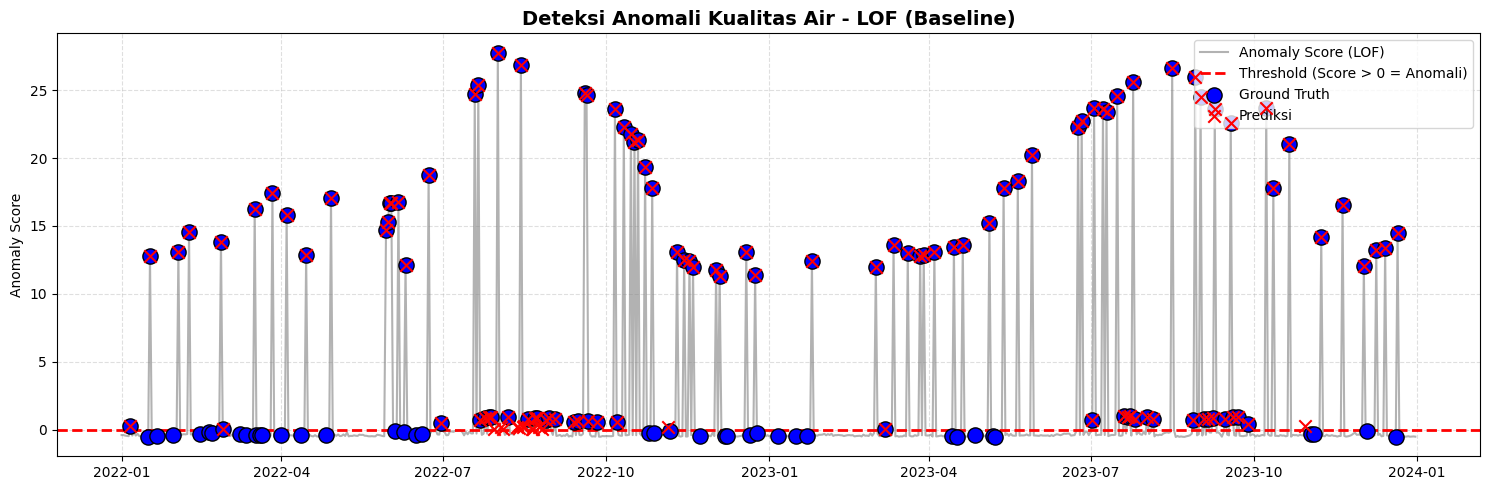

In [210]:
pipeline_lof = AnomalyPipeline('LOF')
prediksi_lof_default = pipeline_lof.run_baseline(train_scaled, test_injected, features)

### Step 10.B - OCSVM Model


 --- MENJALANKAN PIPELINE: OCSVM ---
              precision    recall  f1-score   support

      Normal       0.94      0.99      0.97       586
     Anomali       0.97      0.76      0.86       144

    accuracy                           0.95       730
   macro avg       0.96      0.88      0.91       730
weighted avg       0.95      0.95      0.95       730



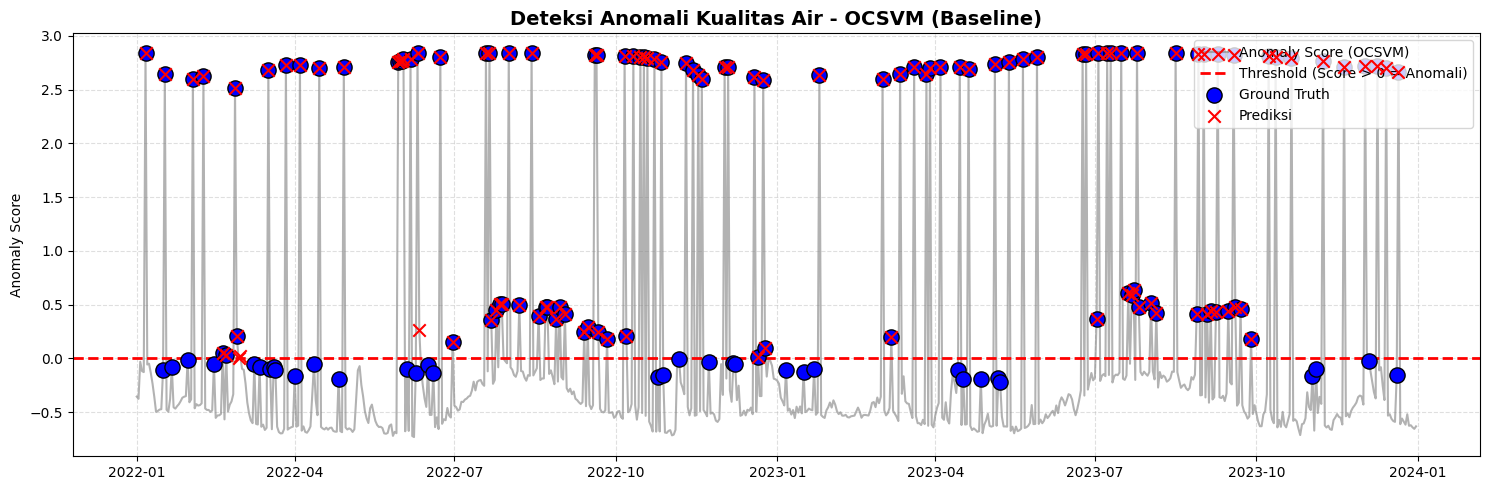

In [211]:
pipeline_svm = AnomalyPipeline('OCSVM')
prediksi_svm_default = pipeline_svm.run_baseline(train_scaled, test_injected, features)

## Step 11 - Heterogeneous Ensemble

In [214]:
test_injected['Prediksi_LOF'] = prediksi_lof_default
test_injected['Prediksi_SVM'] = prediksi_svm_default

test_injected['Total_Vote'] = test_injected['Prediksi_LOF'] + test_injected['Prediksi_SVM']

test_injected['Prediksi_Ensemble'] = test_injected['Total_Vote'].apply(lambda x: 1 if x == 2 else 0)

print("\n--- LAPORAN KLASIFIKASI FINAL ENSEMBLE (TEST SET) ---")
print(classification_report(test_injected['Label'], test_injected['Prediksi_Ensemble'], target_names=['Normal', 'Anomali'], zero_division=0))


--- LAPORAN KLASIFIKASI FINAL ENSEMBLE (TEST SET) ---
              precision    recall  f1-score   support

      Normal       0.94      1.00      0.97       586
     Anomali       1.00      0.74      0.85       144

    accuracy                           0.95       730
   macro avg       0.97      0.87      0.91       730
weighted avg       0.95      0.95      0.94       730



## Step 12 - Ablation Study